Understanding **Feature Importance** is *super useful* for both **interpreting your models** and **acing interviews**, especially when you’re using models like **Random Forests**, **XGBoost**, or even **Logistic Regression**.

Let’s break it down step by step:

---

## 🔍 What is Feature Importance in Machine Learning?

**Feature importance** refers to techniques that assign a score to input features based on how useful they are at predicting a target variable.

### ✨ Why is it important?
- Helps in **dimensionality reduction**.
- Improves **model interpretability**.
- Allows for **feature selection** (removing irrelevant or redundant features).

---

## 🌲 Feature Importance in Random Forest (In-Depth)

Random Forest is an ensemble of decision trees, and it calculates feature importance in two common ways:

### 1. **Mean Decrease in Impurity (MDI)** — *Default in `sklearn`*
Each time a feature is used to split a node, the impurity (e.g., Gini index) is decreased. These decreases are summed and averaged.

### 2. **Permutation Importance**
Shuffle one feature’s values and see how much model performance drops. Bigger drop = more important feature.

---

## 🧠 Interview Tip

**Q: How does Random Forest calculate feature importance?**  
**A:**
> In Random Forest, feature importance is calculated based on the total decrease in node impurity — like Gini or Entropy — brought by that feature across all trees in the forest. This is called "Mean Decrease in Impurity." Alternatively, permutation importance can be used, which measures performance loss after shuffling feature values.

---

## 🧪 Example Code (Hands-on with Random Forest)

We’ll use the classic **Iris Dataset** for this demo.

```python
# Step 1: Import libraries
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Step 3: Train Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Step 4: Get feature importances
importances = model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)

# Step 5: Visualize feature importances
plt.figure(figsize=(8, 5))
sns.barplot(x=feat_importances, y=feat_importances.index)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()
```

---

## 🔁 Bonus: Permutation Importance (More Reliable)

```python
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X, y, n_repeats=10, random_state=42)
perm_sorted_idx = result.importances_mean.argsort()

plt.figure(figsize=(8, 5))
plt.barh(X.columns[perm_sorted_idx], result.importances_mean[perm_sorted_idx])
plt.xlabel("Permutation Importance")
plt.title("Permutation Feature Importance")
plt.show()
```

---

## 🧠 More Interview Questions

### **Q: Why is permutation importance more reliable than impurity-based importance?**  
**A:**  
> Impurity-based importance can be biased toward features with more unique values or high cardinality. Permutation importance evaluates the true impact of each feature on model performance, making it more reliable and model-agnostic.

### **Q: What if two features are highly correlated?**  
**A:**  
> Feature importance scores can be misleading when features are highly correlated. Random Forest may split on one and ignore the other, even if both are important, leading to underestimation of the ignored feature's importance.

---

## ✅ Summary Table

| Method                  | Pros                              | Cons                              |
|------------------------|-----------------------------------|-----------------------------------|
| MDI (Gini Importance)  | Fast, built-in                    | Biased for categorical/numeric with many levels |
| Permutation Importance | Model-agnostic, more reliable     | Slower, needs multiple evaluations |

---



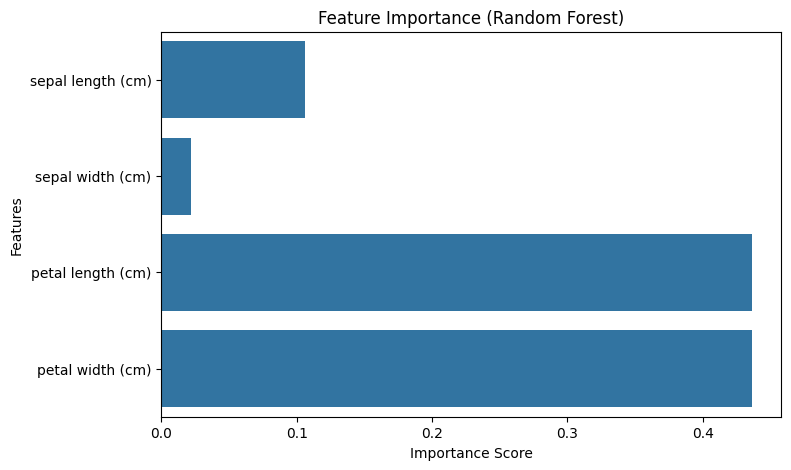

In [1]:
# Step 1: Import libraries
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Step 3: Train Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Step 4: Get feature importances
importances = model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)

# Step 5: Visualize feature importances
plt.figure(figsize=(8, 5))
sns.barplot(x=feat_importances, y=feat_importances.index)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()


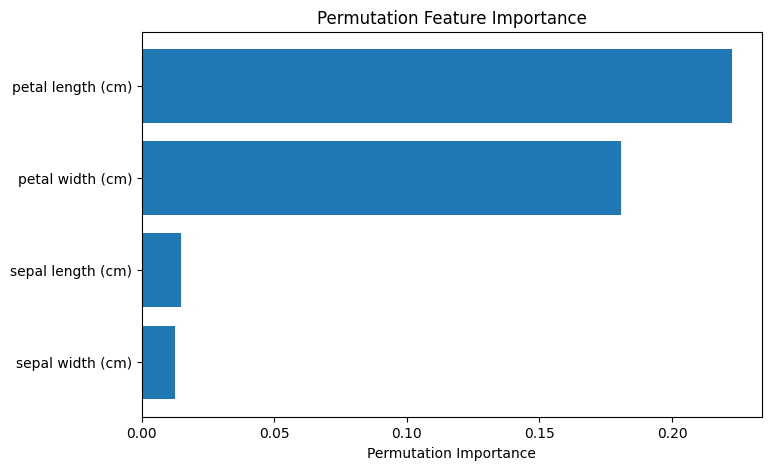

In [7]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X, y, n_repeats=10, random_state=42)
perm_sorted_idx = result.importances_mean.argsort()#This line sorts the indices of
#the features based on their mean importance scores in ascending order.


plt.figure(figsize=(8, 5))
plt.barh(X.columns[perm_sorted_idx], result.importances_mean[perm_sorted_idx])
plt.xlabel("Permutation Importance")
plt.title("Permutation Feature Importance")
plt.show()

Let's go **deep into the math** behind feature importance in Random Forest, and then I’ll walk you through **SHAP (SHapley Additive exPlanations)** — the most powerful method for model explainability today.

---

# 🌳 Part 1: Math Behind Random Forest Feature Importance (MDI)

### ✅ Recap: Gini Impurity (used in Classification Trees)

\[
Gini(p) = 1 - \sum_{i=1}^{C} p_i^2
\]

Where:
- \( C \): number of classes
- \( p_i \): probability of class \( i \) at a node

---

### 📉 When a node is split, impurity decreases. This reduction is:

\[
\Delta i(s, t) = i(t) - p_L \cdot i(t_L) - p_R \cdot i(t_R)
\]

Where:
- \( t \): parent node
- \( t_L, t_R \): left & right child nodes
- \( p_L, p_R \): proportion of samples going to left/right
- \( i(t) \): impurity of node \( t \)

---

### 🔍 Feature Importance for a Feature \( f \)

\[
FI(f) = \sum_{\text{splits on } f} \Delta i(s, t)
\]

In Random Forest:
\[
\text{Feature Importance}(f) = \frac{1}{T} \sum_{t=1}^{T} FI_t(f)
\]
Where:
- \( T \): total trees in forest
- \( FI_t(f) \): importance of feature \( f \) in tree \( t \)

➡️ So **more frequently a feature splits nodes with large impurity reduction**, the more important it is.

---

### 🔥 Limitation (Very Important in Interviews):
- Biased toward continuous features or features with many categories.
- Doesn’t capture **feature interaction effects**.

---

# ⚡ Part 2: SHAP (SHapley Additive exPlanations)

### 💡 What is SHAP?
- Based on **Shapley values** from **cooperative game theory**.
- It tells: **“How much did this feature contribute to this prediction?”**

Imagine features are "players" in a game, and the prediction is the "payout." SHAP finds the fair contribution of each feature.

---

### 📐 SHAP Value Formula (Simplified)

\[
\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|! \cdot (|F| - |S| - 1)!}{|F|!} \left[ f(S \cup \{i\}) - f(S) \right]
\]

Where:
- \( F \): full set of features
- \( S \): subset of features excluding \( i \)
- \( f(S) \): model prediction when only features in \( S \) are used
- \( \phi_i \): SHAP value for feature \( i \)

It averages the **marginal contribution** of feature \( i \) across all possible subsets \( S \).

### ⚠️ It’s computationally expensive: \( O(2^n) \), but optimized methods (like **TreeSHAP**) exist for tree models.

---

### ✅ Properties of SHAP:
| Property         | Meaning |
|------------------|---------|
| **Local accuracy** | Sum of SHAP values = model prediction |
| **Missingness**   | Features not in model = 0 SHAP |
| **Consistency**   | More impact → higher SHAP value |

---

# 👨‍💻 SHAP Code Example (Random Forest or XGBoost)

```python
import shap
import xgboost as xgb
import pandas as pd
from sklearn.datasets import load_boston

# Load data
boston = load_boston()
X = pd.DataFrame(boston.data, columns=boston.feature_names)
y = boston.target

# Train model
model = xgb.XGBRegressor()
model.fit(X, y)

# Explain model predictions using SHAP
explainer = shap.Explainer(model)
shap_values = explainer(X)

# Summary plot
shap.summary_plot(shap_values, X)
```

---

### 🔥 SHAP Plot Breakdown:

- **Summary Plot**: Shows importance + direction (red = high, blue = low feature value).
- **Force Plot**: Explains individual predictions.
- **Dependence Plot**: Shows interaction between features.

---

### ✅ Interview Tip

**Q: What is the difference between SHAP and traditional feature importance in Random Forest?**  
**A:**  
> Traditional importance (like MDI) tells how often a feature is used to split data and how much it reduces impurity. SHAP, on the other hand, calculates the actual contribution of each feature to each individual prediction using game theory, offering a more accurate and consistent explanation.

---

## 🧠 TL;DR Comparison

| Method        | Local | Global | Handles Interaction | Model-Agnostic | Biased?  |
|---------------|-------|--------|----------------------|----------------|----------|
| MDI (RF)      | ❌    | ✅     | ❌                   | ❌             | ✅        |
| Permutation   | ❌    | ✅     | ❌                   | ✅             | ✅ (less) |
| SHAP          | ✅    | ✅     | ✅                   | ✅             | ❌        |

---



this is a **common interview topic**, especially when you talk about **model explainability**. Here's a **complete comparison between SHAP and Traditional Feature Importance (like in Random Forest)** with clear explanations, pros/cons, and interview-ready points.

---

# 🧠 SHAP vs Traditional Feature Importance – Full Comparison

| Feature | **Traditional Importance (Random Forest)** | **SHAP (SHapley Additive exPlanations)** |
|--------|--------------------------------------------|------------------------------------------|
| **Based On** | Impurity Reduction (Gini / Entropy) or Permutation | Game Theory (Shapley values) |
| **Level of Explanation** | Global only | Local + Global |
| **Explanation for Individual Predictions** | ❌ Not possible | ✅ Yes, for every prediction |
| **Captures Feature Interaction** | ❌ No | ✅ Yes |
| **Handles Correlated Features** | ❌ Biased (can split preference) | ✅ Fairly distributes credit |
| **Bias** | Biased towards high-cardinality or numeric features | Unbiased (satisfies fairness axioms) |
| **Model-Specific vs Model-Agnostic** | Usually model-specific (e.g., Random Forest only) | Both: Model-Agnostic & Model-Specific (TreeSHAP, DeepSHAP) |
| **Computational Cost** | Fast | Slower (especially for large models), but TreeSHAP is efficient |
| **Output Type** | Feature importance scores (single value per feature) | SHAP values for each feature per sample |
| **Visualizations** | Bar plots | Summary, force, waterfall, dependence plots |
| **Use in Debugging** | Limited | Very useful (can find why model behaves wrongly) |
| **Interpretability** | Less transparent | High interpretability |

---

## 🔍 Deeper Explanation

### 🎯 Traditional Feature Importance (Random Forest)
- Measures **how much a feature reduces impurity** (Gini/Entropy) across all trees.
- Can also be done using **Permutation Importance** (measure drop in accuracy after shuffling a feature).

**Limitations:**
- Doesn’t explain individual predictions.
- Can be **misleading for correlated features**.
- Tends to overrate **continuous/numerical features**.

---

### 🧮 SHAP (SHapley Additive Explanations)
- Based on **Shapley values from game theory**.
- Fairly allocates contribution of each feature to the prediction.
- Can **visualize and explain every prediction**.

**Strengths:**
- Works with any model (tree, linear, DL, etc.).
- Robust, fair, interpretable.
- Captures both **main effects + interaction effects**.

---

## 🎯 Interview Cracker Answer

**Q: How does SHAP differ from traditional feature importance like Gini-based importance in Random Forest?**

✅ **Sample Answer:**
> Traditional feature importance in Random Forests measures how much each feature decreases impurity across all trees, giving a global view. However, it can be biased toward continuous features and doesn’t provide explanations at an individual prediction level.
>
> SHAP, on the other hand, is based on game theory. It calculates how each feature contributes to every individual prediction, providing both local and global interpretability. It fairly distributes credit among features, even when they're correlated or interacting, making it more trustworthy and transparent for model explanations.

---

## 📈 Visual Summary (if needed)

Imagine this visual hierarchy:

```plaintext
                    ⬇️ Feature Importance Methods ⬇️

               ┌──────────────┐
               │  Traditional │
               └─────┬────────┘
                     │
         ┌───────────┴────────────┐
         │                        │
  Gini-based Importance    Permutation Importance

               ┌────────────┐
               │    SHAP    │
               └────┬───────┘
                    │
    ┌───────────────┴──────────────┐
    │ Explains individual outputs  │
    │ Model-agnostic & consistent  │
    │ Handles interaction & fairness│
```

---



In [9]:
# 📌 Step 1: Load Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import shap

# 📌 Step 2: Load Data
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# 📌 Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 📌 Step 4: Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

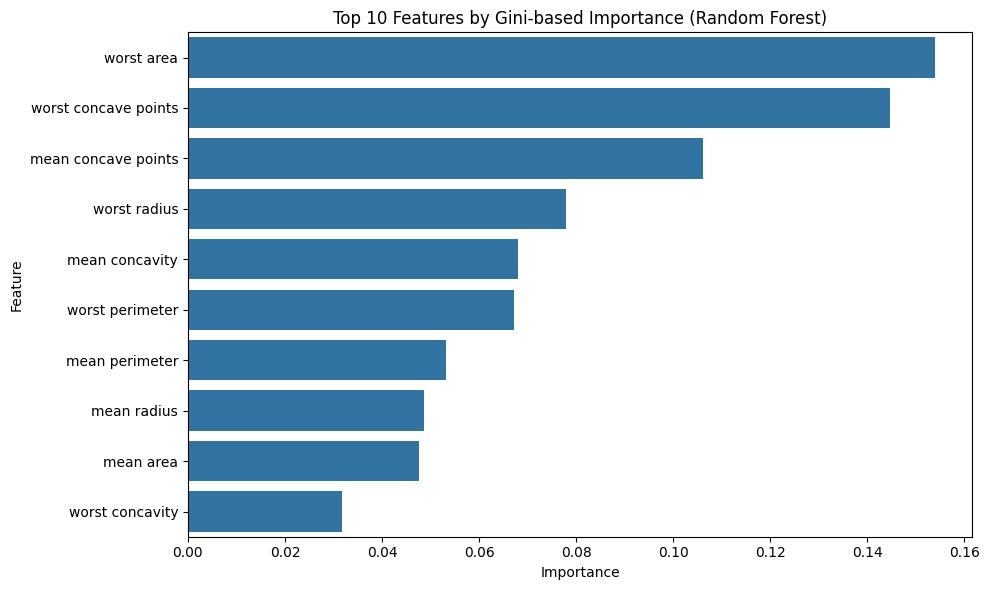

In [10]:
# Feature Importances from Random Forest
importances = model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10))
plt.title("Top 10 Features by Gini-based Importance (Random Forest)")
plt.tight_layout()
plt.show()


In [ ]:
# Init SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

# Summary Plot
shap.summary_plot(shap_values[1], X_train, plot_type="bar")  # Class 1 importance
